# Interactive Force Predictions Debugging

This notebook provides an interactive way to debug force predictions from the BioEmu model. It allows you to:
1. Visualize a single frame and its predicted forces
2. Override the protein configuration
3. Compare forces with different noise levels
4. Visualize the results using nglview

In [1]:
import hydra
import torch
import numpy as np
from bioemu.datasets.fastfolders import FastFolderTrajectory
from bioemu.interpolate import Interpolator
import mdtraj as md
import nglview as nv
from typing import cast
import matplotlib.pyplot as plt

## Configuration

You can modify these parameters to change the protein and other settings:

In [2]:
protein_name = "trp_cage"  # Change this to your protein of interest

# Initialize Hydra (only needs to be done once per session)
hydra.initialize(config_path="../src/bioemu/config")

cfg = hydra.compose(
    config_name="config",
    overrides=[f"protein_name={protein_name}"]
)
print(f"Using protein: {cfg.protein_name}")

Using protein: trp_cage


/tmp/ipykernel_2172896/1271529333.py:4: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(config_path="../src/bioemu/config")
/home/ishan/miniforge3/envs/bioemu/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


## Initialize Model and Load Data

In [3]:
# Initialize trajectory and interpolator
Trajectory = hydra.utils.instantiate(cfg.dataset)
rescaled_protein_trajectory = Trajectory(protein_name=cfg.protein_name, center_scale_traj=True)
rescaled_protein_trajectory = cast(FastFolderTrajectory, rescaled_protein_trajectory)

FastFolderInterpolator = hydra.utils.instantiate(cfg.interpolator)
torch.manual_seed(cfg.seed)
bioemu_interpolator = FastFolderInterpolator(
    dt=cfg.dt,
    path_length=cfg.path_length,
    protein_trajectory=rescaled_protein_trajectory,
)
bioemu_interpolator = cast(Interpolator, bioemu_interpolator)
bioemu_interpolator = bioemu_interpolator.cuda()

Extra atoms in SER: ['OXT']
Removed 1 extra atoms from the topology
Topology has 143 atoms and 278 bonds


## Select and Process Single Frame

In [4]:
print(rescaled_protein_trajectory.topology)
rescaled_protein_trajectory.ground_truth_traj_FAX.shape

<mdtraj.Topology with 1 chains, 20 residues, 143 atoms, 72 bonds>


torch.Size([1044000, 143, 3])

In [5]:
# Select a random frame
frame_idx = np.random.randint(0, len(rescaled_protein_trajectory.ground_truth_traj_FAX) - 1)
next_frame_idx = frame_idx + 1

# Get frames
start_frame_FAX = rescaled_protein_trajectory.ground_truth_traj_FAX[frame_idx].unsqueeze(0)
next_frame_FAX = rescaled_protein_trajectory.ground_truth_traj_FAX[next_frame_idx].unsqueeze(0)

# Convert to backbone representation
start_frame_FAbX = bioemu_interpolator.all_atom_to_backbone(start_frame_FAX)
next_frame_FAbX = bioemu_interpolator.all_atom_to_backbone(next_frame_FAX)

# Get model predictions at different noise levels
noise_levels = [0.01, 0.05, 0.1, 0.2, 0.5, 0.99]
predicted_forces = {}

for t in noise_levels:
    score = bioemu_interpolator.get_forces(start_frame_FAbX.cuda(), t=t)
    # score /= torch.linalg.vector_norm(score, dim=-1, keepdim=True)
    predicted_forces[t] = score.detach().cpu()

## Visualize Structure and Forces

In [6]:
scale = 1.0

# 1. Get the all-atom coordinates and topology for the frame
coords_all_ang = start_frame_FAX.squeeze().cpu().numpy()  # shape (N_atoms, 3)
topology = rescaled_protein_trajectory.topology  # all-atom mdtraj.Topology

# 2. Get the backbone mask and indices
backbone_mask = rescaled_protein_trajectory.backbone_mask_A.numpy()  # shape (N_atoms,)
backbone_indices = np.where(backbone_mask)[0]  # indices of backbone atoms

# 3. Get the backbone coordinates and forces
coords_backbone = coords_all_ang[backbone_indices]  # shape (N_backbone, 3)
forces_backbone = predicted_forces[0.05].squeeze().cpu().numpy()

traj = md.Trajectory(coords_all_ang[None, :, :] / 10, topology)

view = nv.show_mdtraj(traj)
view.clear_representations()
view.add_ball_and_stick()

for i, idx in enumerate(backbone_indices):
    start = coords_all_ang[idx]  # in Angstroms
    start_nm = start / 10    # convert to nm for MDTraj
    end_nm = start_nm + (forces_backbone[i] / 10) * scale  # scale force and convert to nm
    view.shape.add_arrow(start_nm * 10, end_nm * 10, [1, 0, 0], 0.2)  # nglview expects Å

view

NGLWidget()

# AMBER Forces

In [7]:
frame = rescaled_protein_trajectory.ground_truth_traj_FAaX[frame_idx]
if isinstance(frame, torch.Tensor):
    frame = frame.cpu().numpy()

# Create MDTraj trajectory and save as PDB
MAE_traj = md.Trajectory(frame[None, :, :], rescaled_protein_trajectory.og_topology)
MAE_traj.save("mae_all_atom_frame.pdb")

In [8]:
tleap_input = """
source leaprc.protein.ff14SB
addPdbAtomMap {
    { "H"  "H1" }
}
mol = loadpdb mae_all_atom_frame.pdb
saveamberparm mol amber_frame.prmtop amber_frame.inpcrd
quit
"""
with open("tleap.in", "w") as f:
    f.write(tleap_input)
print("Wrote tleap.in")

# Run tleap (uncomment the next line to run in the notebook)
!tleap -f tleap.in

Wrote tleap.in
-I: Adding /home/ishan/miniforge3/envs/bioemu/dat/leap/prep to search path.
-I: Adding /home/ishan/miniforge3/envs/bioemu/dat/leap/lib to search path.
-I: Adding /home/ishan/miniforge3/envs/bioemu/dat/leap/parm to search path.
-I: Adding /home/ishan/miniforge3/envs/bioemu/dat/leap/cmd to search path.
-f: Source tleap.in.

Welcome to LEaP!
(no leaprc in search path)
Sourcing: ./tleap.in
----- Source: /home/ishan/miniforge3/envs/bioemu/dat/leap/cmd/leaprc.protein.ff14SB
----- Source of /home/ishan/miniforge3/envs/bioemu/dat/leap/cmd/leaprc.protein.ff14SB done
Log file: ./leap.log
Loading parameters: /home/ishan/miniforge3/envs/bioemu/dat/leap/parm/parm10.dat
Reading title:
PARM99 + frcmod.ff99SB + frcmod.parmbsc0 + OL3 for RNA
Loading parameters: /home/ishan/miniforge3/envs/bioemu/dat/leap/parm/frcmod.ff14SB
Reading force field modification type file (frcmod)
Reading title:
ff14SB protein backbone and sidechain parameters
Loading library: /home/ishan/miniforge3/envs/bioemu

In [9]:
sander_input = """
Single point force calculation
&cntrl
  imin = 0,        ! Do MD instead of minimization
  ntx = 1,         ! Read coordinates, no velocities
  irest = 0,       ! Fresh run
  nstlim = 1,      ! Take one MD step
  dt = 0.00001,    ! Tiny timestep
  ntb = 0,         ! Non-periodic
  cut = 20.0,      ! Large cutoff
  ntpr = 1,        ! Print energy
  ntwx = 1,        ! Write coordinates to mdcrd
  ntwv = 1,        ! Write forces to mdvel
  ioutfm = 1,      ! Output format: NetCDF
  ntf = 1,         ! Calculate all forces
  ntc = 1,         ! No SHAKE
  ntwr = 1         ! Write restart file
/
"""

# Run sander - specify both coordinate and velocity output files
!sander -O -i force.in -p amber_frame.prmtop -c amber_frame.inpcrd -o force.out -x mdcrd -v mdvel

In [10]:
import netCDF4 as nc
import numpy as np

# Read the mdvel NetCDF file directly
with nc.Dataset('mdvel', 'r') as ncfile:
    forces_raw = ncfile.variables['velocities'][0]
    scale_factor = ncfile.variables['velocities'].scale_factor
    amber_forces_AaX = np.array(forces_raw) * scale_factor
amber_forces_AaX = torch.Tensor(amber_forces_AaX)
amber_forces_AX = amber_forces_AaX[rescaled_protein_trajectory.og_to_filtered_topology_mask][rescaled_protein_trajectory.og_to_filtered_topology_order]
amber_forces_AbX = amber_forces_AX[rescaled_protein_trajectory.backbone_mask_A]
amber_forces_FAbX = amber_forces_AbX.unsqueeze(0)
print(f"Scale factor: {scale_factor}")
print(f"Forces shape: {amber_forces_AaX.shape}")
print(f"Forces (first 5 atoms):\n{amber_forces_AaX[:5]}")
print(f"Force magnitudes (first 5 atoms): {np.linalg.norm(amber_forces_AaX[:5], axis=1)}")

Scale factor: 20.455
Forces shape: torch.Size([272, 3])
Forces (first 5 atoms):
tensor([[ 0.0369,  0.0730, -0.1673],
        [ 0.2346, -0.7841,  1.0351],
        [-0.9740, -0.7162,  0.8738],
        [-0.3462,  0.5442,  0.9774],
        [ 0.1240,  0.1952, -0.0144]])
Force magnitudes (first 5 atoms): [0.18617223 1.3195617  1.4917045  1.171056   0.231759  ]


## Compare Forces

Calculate cosine similarity between displacement-based forces and model predictions:

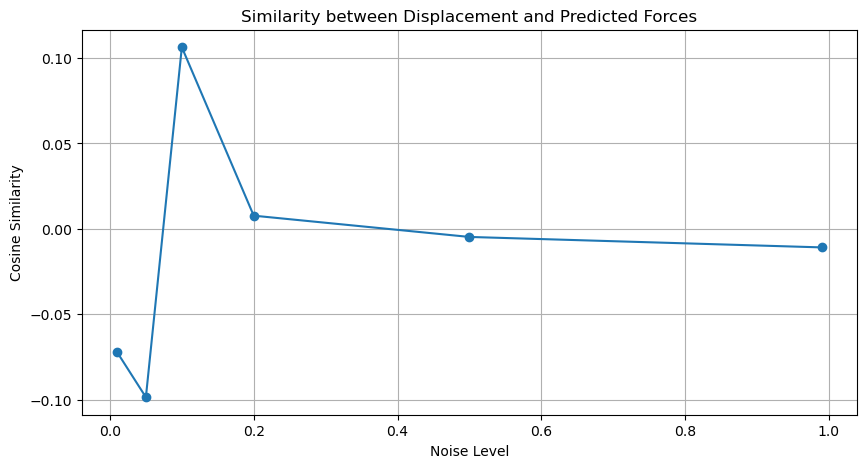

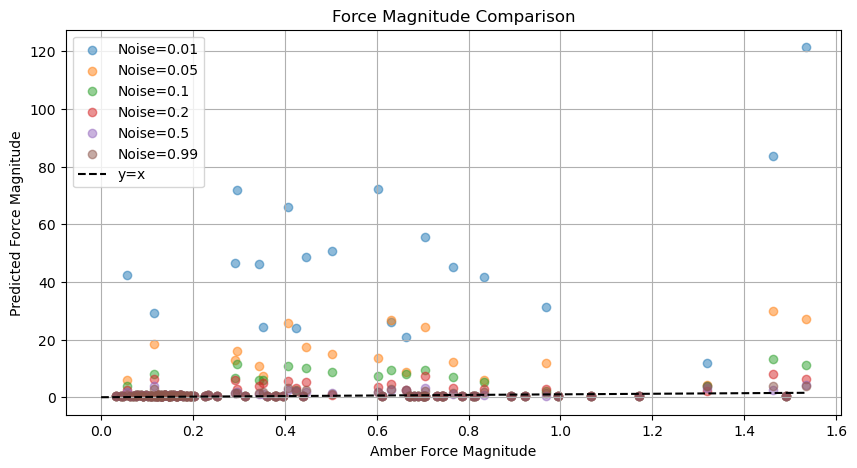

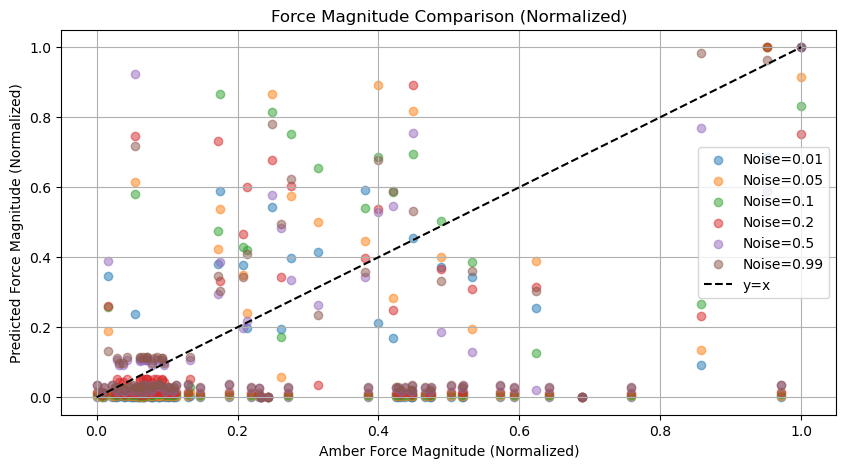

In [11]:
similarities = {}
for t, forces_FAbX in predicted_forces.items():
    similarity = torch.einsum("fax,fax->fa", amber_forces_FAbX, forces_FAbX)
    similarity /= torch.linalg.vector_norm(amber_forces_FAbX, dim=-1) * torch.linalg.vector_norm(forces_FAbX, dim=-1)
    similarities[t] = similarity.mean().item()

plt.figure(figsize=(10, 5))
plt.plot(list(similarities.keys()), list(similarities.values()), 'o-')
plt.xlabel("Noise Level")
plt.ylabel("Cosine Similarity")
plt.title("Similarity between Displacement and Predicted Forces")
plt.grid(True)
plt.show()

# Create scatter plot comparing force magnitudes
plt.figure(figsize=(10, 5))
for t, forces_FAbX in predicted_forces.items():
    amber_force_mags = torch.linalg.vector_norm(amber_forces_FAbX, dim=-1).flatten()
    pred_force_mags = torch.linalg.vector_norm(forces_FAbX, dim=-1).flatten()
    plt.scatter(amber_force_mags, pred_force_mags, alpha=0.5, label=f'Noise={t}')

plt.plot([0, amber_force_mags.max()], [0, amber_force_mags.max()], 'k--', label='y=x')
plt.xlabel('Amber Force Magnitude')
plt.ylabel('Predicted Force Magnitude') 
plt.title('Force Magnitude Comparison')
plt.legend()
plt.grid(True)
plt.show()


# Create scatter plot comparing force magnitudes
plt.figure(figsize=(10, 5))
for t, forces_FAbX in predicted_forces.items():
    amber_force_mags = torch.linalg.vector_norm(amber_forces_FAbX, dim=-1).flatten()
    pred_force_mags = torch.linalg.vector_norm(forces_FAbX, dim=-1).flatten()
    
    # # Normalize to [0,1] range
    # amber_force_mags = amber_force_mags / amber_force_mags.max()
    # pred_force_mags = pred_force_mags / pred_force_mags.max()
    
    # # Filter out points with predicted force magnitude > 0.2
    # mask = pred_force_mags <= 0.2
    # amber_force_mags = amber_force_mags[mask]
    # pred_force_mags = pred_force_mags[mask]
    
    # # normalize again (after removing outliers)
    amber_force_mags = (amber_force_mags - amber_force_mags.min())/ (amber_force_mags.max() - amber_force_mags.min())
    pred_force_mags = (pred_force_mags - pred_force_mags.min()) / (pred_force_mags.max() - pred_force_mags.min())
    
    plt.scatter(amber_force_mags, pred_force_mags, alpha=0.5, label=f'Noise={t}')

plt.plot([0, 1], [0, 1], 'k--', label='y=x')
plt.xlabel('Amber Force Magnitude (Normalized)')
plt.ylabel('Predicted Force Magnitude (Normalized)') 
plt.title('Force Magnitude Comparison (Normalized)')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
view = nv.show_mdtraj(MAE_traj)
view.clear_representations()
view.add_ball_and_stick()

# for i, idx in enumerate(backbone_indices):
#     start = coords_all_ang[idx]  # in Angstroms
#     start_nm = start / 10    # convert to nm for MDTraj
#     end_nm = start_nm + (forces_backbone[i] / 10) * scale  # scale force and convert to nm
#     view.shape.add_arrow(start_nm * 10, end_nm * 10, [1, 0, 0], 0.2)  # nglview expects Å

view

NGLWidget()